In [1]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

MODELS_PATH = Path("/home/solan/repos/airi-research/models")
# MODELS_PATH = Path("/home/hse_student/a.soldatov/models")

DATA_DIR_PATH = Path("/home/solan/repos/airi-research/data")
# DATA_DIR_PATH = Path(
#     "/home/HDD12TB/datasets/images/emotions/ACMMM25/AVI/AVI_Challenge_dataset"
# )

TRAIN_DIR_PATH = DATA_DIR_PATH / "train_data"

PREPROCESSED_TRAIN_DIR_PATH = DATA_DIR_PATH / "preprocessed_train_data"
PREPROCESSED_VAL_DIR_PATH = DATA_DIR_PATH / "preprocessed_val_data"
PREPROCESSED_TEST_DIR_PATH = DATA_DIR_PATH / "preprocessed_test_data"

In [2]:
import pandas as pd

df_train = pd.read_csv(PREPROCESSED_TRAIN_DIR_PATH / "train_data.csv")
df_val = pd.read_csv(PREPROCESSED_VAL_DIR_PATH / "val_data.csv")
df_test = pd.read_csv(PREPROCESSED_TEST_DIR_PATH / "test_data.csv")

df_train

,id,age,work_experience,Honesty-Humility,Extraversion,Agreeableness,Conscientiousness,Integrity,Collegiality,Social_versatility,...,education_6,education_7,race_0,race_1,race_2,race_3,race_4,race_5,race_6,has_glasses
0,60fccc84440f8e8c82ca0288,0.061224,0.000000,3.781250,3.806250,4.006250,3.668750,4.0,3.9,4.0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,639881e5774909b88ee9389a,0.693878,0.666667,3.918750,3.475000,3.950000,4.100000,3.6,2.4,2.5,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,60e1d5f866e681d7e33fd01c,0.448980,0.529412,3.075000,2.912500,2.612500,3.562500,3.5,2.5,2.5,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,62ceba5fdab49dfc90278cbb,0.102041,0.098039,3.970000,2.725000,3.312500,3.381250,3.2,3.1,3.3,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,6134113b9f3f724a7cf9e390,0.204082,0.235294,3.037500,2.825000,3.062500,2.931250,3.5,3.5,3.5,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,5fbd371dc57ae80a38ba00c2,0.306122,0.196078,3.608333,3.416667,3.716667,3.558333,3.5,4.0,3.7,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
446,5a95fee189de8200013eddd4,0.448980,0.392157,3.368750,2.812500,2.912500,2.893750,3.5,2.9,2.9,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
447,629a6460a0232815dab01a01,0.265306,0.137255,3.368750,3.075000,3.443750,3.162500,2.9,3.1,2.9,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
448,5db5dacdb2d499000a8f4439,0.285714,0.254902,3.162500,3.118750,3.643750,3.062500,3.0,3.8,3.5,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [3]:
postfixes = [
    "_q1_generic",
    "_q2_generic",
    "_q3_personality",
    "_q4_personality",
    "_q5_personality",
    "_q6_personality",
]
meta_columns = [
    "age",
    "work_experience",
    *[f"gender_{i}" for i in range(1, 5)],
    *[f"education_{i}" for i in range(1, 8)],
]
meta_columns

['age',
 'work_experience',
 'gender_1',
 'gender_2',
 'gender_3',
 'gender_4',
 'education_1',
 'education_2',
 'education_3',
 'education_4',
 'education_5',
 'education_6',
 'education_7']

# Video


## Race


In [5]:
index2race = {
    0: "White",
    1: "Black",
    2: "Latino_Hispanic",
    3: "East Asian",
    4: "Southeast Asian",
    5: "Indian",
    6: "Middle Eastern",
}

In [6]:
import torch
import torch.nn as nn
import torchvision

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# fair_face_model = torch.load

model_fair_7 = torchvision.models.resnet34(pretrained=True)
model_fair_7.fc = nn.Linear(model_fair_7.fc.in_features, 18)
model_fair_7.load_state_dict(
    torch.load(MODELS_PATH / "res34_fair_align_multi_7_20190809.pt")
)
model_fair_7 = model_fair_7.to(device)
model_fair_7.eval()

/home/solan/repos/airi-research/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/solan/repos/airi-research/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
from torchvision import transforms

trans = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [8]:
_id = "60fccc84440f8e8c82ca0288"
_id = "63d13dbf2d8a41f897c4d8fd"
_id = "63b73bd5a6179e2e7297d96e"
# _id = "5fa4c21a04bc5912180291bc"

_id

'63b73bd5a6179e2e7297d96e'

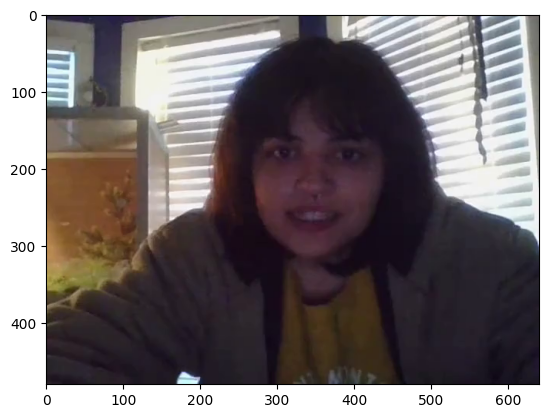

In [9]:
video_path = TRAIN_DIR_PATH / f"{_id}{postfixes[1]}.mp4"

video = cv2.VideoCapture(str(video_path))
fps = video.get(cv2.CAP_PROP_FPS)
num_frames = video.get(cv2.CAP_PROP_FRAME_COUNT)
duration = num_frames / fps

while True:
    ret, frame = video.read()

    if (frame != 0).any():
        break

    if not ret:
        break

video.release()

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame)

/home/solan/repos/airi-research/data/preprocessed_train_data/video/63b73bd5a6179e2e7297d96e_q1_generic/00000.png
2 Latino_Hispanic


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..-0.16568205].


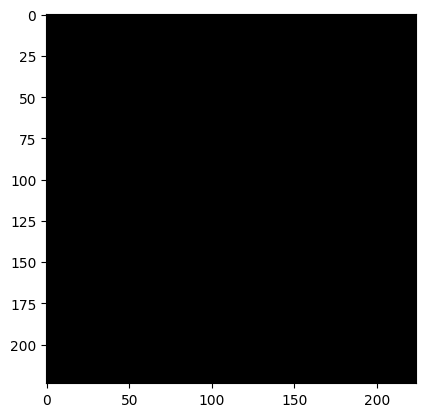

In [10]:
from einops import rearrange
import numpy as np


video_path = PREPROCESSED_TRAIN_DIR_PATH / "video" / f"{_id}{postfixes[0]}"

for frame_path in sorted(video_path.glob("*.png")):
    print(frame_path)

    image = cv2.imread(str(frame_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # skip if no face
    if (image == 0).all():
        continue

    image = trans(image)
    image = image.view(
        1, 3, 224, 224
    )  # reshape image to match model dimensions (1 batch size)
    image = image.to(device)

    outputs = model_fair_7(image)
    outputs = outputs.cpu().detach().numpy()

    race_outputs = outputs[:, :7]

    race_score = np.exp(race_outputs) / np.sum(np.exp(race_outputs))
    race_pred = np.argmax(race_score)
    print(race_pred, index2race[race_pred])

    # image = (image + 2) / 2 * 255
    plt.imshow(rearrange(image.cpu(), "1 c h w -> h w c"))

    break

In [11]:
arr = [0, 1, 0, 4, 5, 6]
arr = np.eye(7)[arr]
arr

array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
NoneType = type(None)


def update_with_race_df(
    df: pd.DataFrame,
    csv: str,
    preprocessed_dir_path: Path,
    # dir_path: Path,
):
    races = []
    for _, row in df.iterrows():
        race = None
        for postfix in postfixes:
            if not isinstance(race, NoneType):  # quit if race were predicted
                break

            video_id = f"{row['id']}{postfix}"
            video_path = preprocessed_dir_path / "video" / video_id

            for frame_path in sorted(video_path.glob("*.png")):
                image = cv2.imread(str(frame_path))
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                assert image.dtype == np.uint8

                # skip if no face
                if (image != 0).any():
                    image = trans(image)
                    image = image.view(
                        1, 3, 224, 224
                    )  # reshape image to match model dimensions (1 batch size)
                    image = image.to(device)

                    outputs = model_fair_7(image)
                    outputs = outputs.cpu().detach().numpy()

                    race_outputs = outputs[:, :7]

                    race_score = np.exp(race_outputs) / np.sum(np.exp(race_outputs))
                    race_pred = np.argmax(race_score)

                    # assign race number
                    race = race_pred
                    break

        # if still no race is determined
        if isinstance(race, NoneType):
            race = -1

        races.append(race)

    if "race" in df.columns:
        df.drop(columns="race", inplace=True)

    races = np.eye(7)[races]  # one hot encoding
    race_columns = [f"race_{i}" for i in range(7)]
    df[race_columns] = pd.DataFrame(races, index=df.index)
    df.to_csv(preprocessed_dir_path / csv, index=False)

In [15]:
update_with_race_df(df_train, "train_data.csv", PREPROCESSED_TRAIN_DIR_PATH)

In [16]:
update_with_race_df(df_val, "val_data.csv", PREPROCESSED_VAL_DIR_PATH)

In [17]:
update_with_race_df(df_test, "test_data.csv", PREPROCESSED_TEST_DIR_PATH)

## Glasses


In [27]:
_id = "63b73bd5a6179e2e7297d96e"
# _id = "5fa4c21a04bc5912180291bc"

_id

'63b73bd5a6179e2e7297d96e'

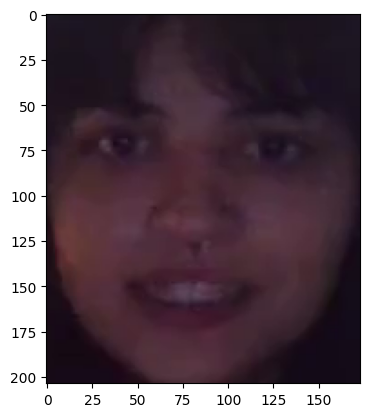

In [ ]:
image_path = PREPROCESSED_TRAIN_DIR_PATH / "video" / f"{_id}{postfixes[1]}/00000.png"

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

In [32]:
from glasses_detector import GlassesClassifier

# Generates a CSV with each line "<img_name.jpg>,<True|False>"
classifier = GlassesClassifier(size="medium", kind="anyglasses")

image = cv2.resize(image, (256, 256))
classifier.predict(image, format="int")

0

In [ ]:
from glasses_detector import GlassesClassifier


def update_with_glasses_df(
    df: pd.DataFrame,
    csv: str,
    preprocessed_dir_path: Path,
    # dir_path: Path,
):
    classifier = GlassesClassifier(size="medium", kind="anyglasses")

    glasses = []
    for _, row in df.iterrows():

        has_glasses = None
        for postfix in postfixes:
            if not isinstance(has_glasses, NoneType):
                break

            video_id = f"{row['id']}{postfix}"
            video_path = preprocessed_dir_path / "video" / video_id

            for frame_path in sorted(video_path.glob("*.png")):
                image = cv2.imread(str(frame_path))
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                assert image.dtype == np.uint8

                # skip if no face
                if (image != 0).any():

                    image = cv2.resize(image, (256, 256))
                    has_glasses = classifier.predict(image, format="int")
                    break

        # if still no race is determined
        if isinstance(has_glasses, NoneType):
            has_glasses = False

        glasses.append(has_glasses)

    df["has_glasses"] = glasses
    df.to_csv(preprocessed_dir_path / csv, index=False)

In [36]:
update_with_glasses_df(df_train, "train_data.csv", PREPROCESSED_TRAIN_DIR_PATH)

In [35]:
update_with_glasses_df(df_val, "val_data.csv", PREPROCESSED_VAL_DIR_PATH)

In [37]:
update_with_glasses_df(df_test, "test_data.csv", PREPROCESSED_TEST_DIR_PATH)

## Engagement


In [4]:
_id = "63b73bd5a6179e2e7297d96e"  # engaged chica
# _id = "5fa4c21a04bc5912180291bc"  # whole with black man
# _id = "6373aee9c736637f71011482"
# _id = "5c580c3dd3cc6b0001d9ffbf"

_id

'63b73bd5a6179e2e7297d96e'

In [5]:
from IPython.display import Video

video_path = TRAIN_DIR_PATH / f"{_id}{postfixes[0]}.mp4"
Video(video_path)

In [6]:
video_path = PREPROCESSED_TRAIN_DIR_PATH / "video" / f"{_id}{postfixes[0]}"

face_imgs = []
for face_path in video_path.glob("*.png"):
    image = cv2.imread(str(face_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_imgs.append(image)

len(face_imgs)

62

In [7]:
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

emoti_eff = EmotiEffLibRecognizer(
    model_name="enet_b0_8_best_vgaf",
    device="cpu",
    engine="torch",
)

engagement_list, logits = emoti_eff.predict_engagement(face_imgs, 10)
engagement_rate = engagement_list.count("Engaged") / len(engagement_list)
engagement_rate

2025-06-30 21:26:51.956368: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-30 21:26:52.086393: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751308012.134585   24032 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751308012.148716   24032 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-30 21:26:52.270091: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ImportError: ('Looks like torch module is not installed: ', ImportError('libnccl.so.2: cannot open shared object file: No such file or directory'))

In [ ]:
from tqdm import tqdm
from emotiefflib.facial_analysis import EmotiEffLibRecognizer


def update_with_engagement_df(
    df: pd.DataFrame,
    csv: str,
    preprocessed_dir_path: Path,
    # dir_path: Path,
):
    emoti_eff = EmotiEffLibRecognizer(
        model_name="enet_b0_8_best_vgaf",
        device="cpu",
        engine="torch",
    )

    overall_engagements = []
    q1_engagement = []
    q2_engagement = []
    q3_engagement = []
    q4_engagement = []
    q5_engagement = []
    q6_engagement = []

    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        overall_engagement = 0.0

        for postfix in postfixes:
            video_id = f"{row['id']}{postfix}"
            video_path = preprocessed_dir_path / "video" / video_id

            face_imgs = []
            for face_path in video_path.glob("*.png"):
                image = cv2.imread(str(face_path))
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                face_imgs.append(image)

            if len(face_imgs) >= 10:
                engagement_list, logits = emoti_eff.predict_engagement(face_imgs, 10)
                engagement_rate = engagement_list.count("Engaged") / len(
                    engagement_list
                )
            else:
                engagement_rate = 0.0

            if "q1" in postfix:
                q1_engagement.append(engagement_rate)
            elif "q2" in postfix:
                q2_engagement.append(engagement_rate)
            elif "q3" in postfix:
                q3_engagement.append(engagement_rate)
            elif "q4" in postfix:
                q4_engagement.append(engagement_rate)
            elif "q5" in postfix:
                q5_engagement.append(engagement_rate)
            elif "q6" in postfix:
                q6_engagement.append(engagement_rate)
            else:
                raise ValueError(f"No q-nth in postfix: {postfix}")

            overall_engagement += engagement_rate

        overall_engagements.append(overall_engagement / 6)

    df["q1_engagement"] = q1_engagement
    df["q2_engagement"] = q2_engagement
    df["q3_engagement"] = q3_engagement
    df["q4_engagement"] = q4_engagement
    df["q5_engagement"] = q5_engagement
    df["q6_engagement"] = q6_engagement
    df["overall_engagement"] = overall_engagement
    df.to_csv(preprocessed_dir_path / csv, index=False)

In [12]:
update_with_engagement_df(df_val, "val_data.csv", PREPROCESSED_VAL_DIR_PATH)

KeyboardInterrupt: 

---


# Audio
